### This ANALYSYS notebook 

- 

In [232]:
import duckdb
import pandas as pd
from pathlib import Path
import diskcache
from itertools import chain

import igraph as ig
import cairo
import seaborn as sns
import matplotlib.pyplot as plt

from utils.pandas_setup import pandas_setup
pandas_setup()
from IPython.display import display

import pyalex
from pyalex import Works, Authors, Sources, Institutions, Topics, Publishers, Funders
pyalex.config.email = "Lawrence.Cram@anu.edu.au"
pyalex.config.max_retries = 0
pyalex.config.retry_backoff_factor = 0.1
pyalex.config.retry_http_codes = [429, 500, 503]

MY_DATA_PATH = Path('../DATA/')
MY_DATABASE_FILE = Path(MY_DATA_PATH / 'econ.duckdb')
MY_CACHE_FILE = Path('/home/lc/m/.cache/economicsbusiness/cache.db')
DATAFILES_PATH = Path('../DATAFILES')

In [233]:
class SetUp:

    def __init__(self):
        self._setup_db()
        self._setup_cache()
        return
    
    def _setup_db(self):
        self.db = duckdb.connect(MY_DATABASE_FILE)
        self.db.sql(""" SET memory_limit = '56GB';
                        SET threads = 6;
                        SET preserve_insertion_order = false;
                        SET order_by_non_integer_literal=true;
                        SET enable_progress_bar = true;
                        SET temp_directory = '/home/lc/m/.tmp';
                    """)
        self.db.sql("SHOW ALL TABLES").show()
        return
    
    def _setup_cache(self):
        self.cache = diskcache.Cache(MY_CACHE_FILE, size_limit=16_000_000_000)
        print(f'{self.cache.check() = }')
        print(f'{self.cache.volume() = }')
        return
    
    def name_of_global_obj(self, obj=None):
        for objname, oid in globals().items():
            if oid is obj:
                return objname

In [234]:
class TimeSeries(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def basic_time_series(self):
        print('basic time series')
        sql = """
            SELECT publication_year AS 'publication_year', 
                    count(work_id) AS 'works_count',
                    sum(cited_by_count)/count(work_id) AS 'mean_cites',
                    sum(referenced_works_count)/count(work_id) AS 'mean_references'
                FROM workssudo apt-get install libcairo2-dev
                GROUP BY publication_year
                ORDER BY publication_year
            """
        df = self.db.sql(sql).df()
        print(f'{df.shape = }\n{df.head()}')
        self.plot_basic_time_series(df=df)
        return
    
    def count_types(self):
        t = self.db.sql("""
                            SELECT type, count(work_id) AS count 
                                FROM works WHERE contains('article review preprint letter', type) = true 
                                GROUP BY type 
                                ORDER BY count DESC""").df()
        print(f'{t.shape = }\n{t.head(9)}')
        return
    
    def plot_basic_time_series(self, df=None):
        fig, ax = plt.subplots(1, 1)
        sns.lineplot(df, x='publication_year', y='mean_references', ax=ax)
        ax.set_ylim((0, 50))
        ax.set_xlim((2010, 2025))
        plt.show()

        fig, ax = plt.subplots(1, 1)
        sns.lineplot(df, x='publication_year', y='works_count', ax=ax)
        ax.set_ylim((0, 50000))
        ax.set_xlim((2010, 2025))
        plt.show()
        return

    def authorship_time_series(self):
        sql = """
                SELECT DISTINCT author_id, 
                                author_name AS 'author name',
                                works_count,
                                cites_count,
                                cites_count//works_count AS cites_per_work,
                                start_year,
                                end_year,
                                -- publication_years,
                                works_count//(1+end_year-start_year) AS 'pub_rate_per_year'
                    FROM
                        (SELECT author_id,
                                author_name,
                                count(DISTINCT work_id) AS works_count,
                                sum(cited_by_count) AS cites_count,
                                min(publication_year) AS start_year,
                                max(publication_year) AS end_year,
                                -- list(publication_year) AS publication_years
                            FROM authorships a
                                LEFT JOIN works w
                                USING (work_id)
                                WHERE contains('article review preprint letter', w.type) = true 
                                    -- AND w.title != 'Frontmatter'
                                GROUP BY author_id, author_name
                        )
                    ORDER BY works_count DESC --cites_per_work DESC -- pub_rate_per_year DESC --works_count DESC
            """
        df = self.db.sql(sql).df()
        df.to_csv('../DATA/authorship_time_series.csv')
        return
    
    def journal_edge_list(self):
        # SQL code to assemble the source-source edge list with the count of work-work citations as weights
        sql = """
        CREATE OR REPLACE TABLE econ.source_citations AS
        SELECT --sub.work_id,
                --sub.cited_id,
                sub.source_id AS citer_id,
                ww.source_id AS cited_id,
                count(ww.work_id) AS weights,
        FROM
            (SELECT w.work_id,
                    w.source_id,
                    w.cited_by_count,
                    unnest(c.referenced_works) AS cited_id
            FROM works w
            LEFT JOIN cited c
            USING (work_id)
            WHERE w.source_id NOT NULL) sub 
            
        LEFT JOIN works ww
            ON ww.work_id = sub.cited_id
            WHERE ww.source_id NOT NULL
        GROUP BY sub.source_id, ww.source_id
        ORDER BY weights DESC
        """
        self.db.sql(sql)
        return

    def journal_citations(self):
        df = self.db.sql("SELECT * FROM econ.source_citations").df()
        df = df[df.citer_id != df.cited_id]
        df = df[df.weights > 1000]
        print(f'{df.shape = }\n{df.head()}')
        g = ig.Graph.DataFrame(df, directed=True, use_vids=False)
        layout = g.layout(layout="circle")
        fig, ax = plt.subplots()
        ig.plot(g, bbox=(0, 0, 100, 100), target=ax, layout=layout, vertex_size=2, edge_width=1, edge_arrow_width=1)
        plt.show()
        return

In [235]:
class Distributions(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def source_works(self):
        df = self.db.sql("SELECT * FROM works").df()[['work_id', 'source_id']]
        print(f'{df.shape = }\n{df.head()}')
        source_counts = df.groupby('source_id').work_id.count().reset_index().\
            rename(columns={'work_id': 'work_count'}).sort_values(['work_count'], ascending=[True]).reset_index(drop=True).reset_index()
        print(source_counts.head())
        print(source_counts.tail())
        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(source_counts, x='index', y='work_count', color='black', size=1)
        ax.set_xlim(1, 1000)
        ax.set_ylim(10, 10000)
        ax.set_yscale('log')
        ax.set_xscale('log')
        plt.show()        
        return
    
    def institutions_works(self):
        df = self.db.sql("SELECT DISTINCT work_id, institution_id FROM authorships").df()[['work_id', 'institution_id']]
        print(f'{df.shape = }\n{df.head()}')
        institution_counts = df.groupby('institution_id').work_id.count().reset_index().\
            rename(columns={'work_id': 'work_count'}).sort_values(['work_count'], ascending=[True]).reset_index(drop=True).reset_index()
        print(institution_counts.head())
        print(institution_counts.tail())
        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(institution_counts, x='index', y='work_count', color='black', size=1)
        ax.set_xlim(20000, 22000)
        ax.set_ylim(10, 10000)
        ax.set_yscale('log')
        ax.set_xscale('log')
        plt.show()        
        return

In [236]:
def main():

    # ts = TimeSeries()        # source_counts = df.groupby('source_id').work_id.count().reset_index().\
        #     rename(columns={'work_id': 'work_count'}).sort_values(['work_count'], ascending=[False]).reset_index(drop=True)
        # print(source_counts.head())
        # print(source_counts.tail())
    # ts.basic_time_series()
    # ts.authorship_time_series()
    # ts.count_types()
    # ts.journal_edge_list()
    # ts.journal_citations()

    d = Distributions()
    d.source_works()
    d.institutions_works()

┌──────────┬─────────┬───────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

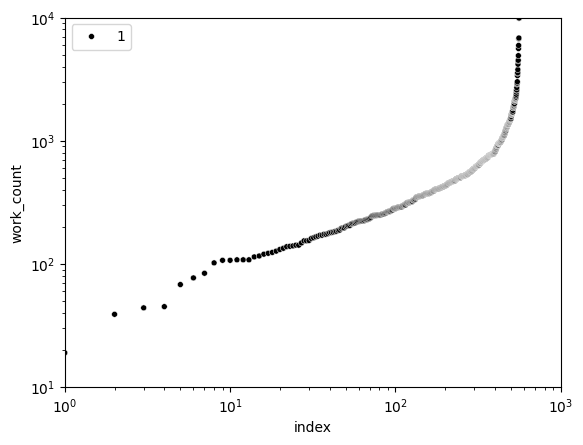

df.shape = (752441, 2)
                            work_id                    institution_id
0  https://openalex.org/W3217637361  https://openalex.org/I2279609970
1  https://openalex.org/W4360616345    https://openalex.org/I32574673
2  https://openalex.org/W4387058343   https://openalex.org/I159176309
3  https://openalex.org/W1969253071    https://openalex.org/I94626330
4  https://openalex.org/W1977183010  https://openalex.org/I4210091150
   index                    institution_id  work_count
0      0  https://openalex.org/I2802282791           1
1      1  https://openalex.org/I2802262932           1
2      2  https://openalex.org/I2802257478           1
3      3  https://openalex.org/I2802254404           1
4      4  https://openalex.org/I2802235131           1
       index                    institution_id  work_count
21778  21778    https://openalex.org/I95457486        2666
21779  21779  https://openalex.org/I1321305853        3013
21780  21780  https://openalex.org/I1294671590    

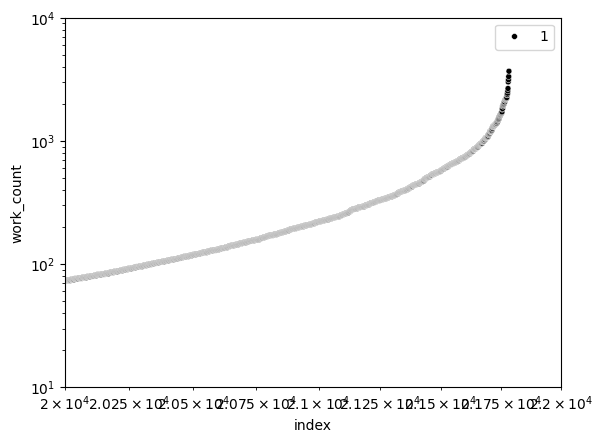

DONE!


In [237]:
if __name__ == "__main__":
    main()
    print("DONE!")